# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [2]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.2 MB 10.7 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.2 MB 10.5 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.2 MB 10.9 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 10.3 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 9.6 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------------------- -------- 1.8/2.3 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 9.6 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- ----------------

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["val_bpb"] = pd.to_numeric(df["val_bpb"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 7
Columns: ['commit', 'val_bpb', 'memory_gb', 'status', 'description']


,commit,val_bpb,memory_gb,status,description
0,24d4e9e,0.000000,0.0,CRASH,baseline
1,24d4e9e,0.000000,0.0,CRASH,embedding_lr=1.0
2,24d4e9e,1.782808,0.2,KEEP,matrix_lr=0.03
3,24d4e9e,1.771936,0.2,KEEP,matrix_lr=0.025
4,24d4e9e,1.763183,0.2,KEEP,warmdown_ratio=0.4
5,24d4e9e,1.748980,0.2,KEEP,depth=3 batch=2
6,24d4e9e,1.751848,0.2,DISCARD,embedding_lr=1.0


In [4]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
KEEP       4
CRASH      2
DISCARD    1

Keep rate: 4/5 = 80.0%


In [5]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    bpb = row["val_bpb"]
    desc = row["description"]
    print(f"  #{i:3d}  bpb={bpb:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (4 total):

  #  2  bpb=1.782808  mem=0.2GB  matrix_lr=0.03
  #  3  bpb=1.771936  mem=0.2GB  matrix_lr=0.025
  #  4  bpb=1.763183  mem=0.2GB  warmdown_ratio=0.4
  #  5  bpb=1.748980  mem=0.2GB  depth=3 batch=2


## Val BPB Over Time

Track how the best (kept) val_bpb evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

NameError: name 'best' is not defined

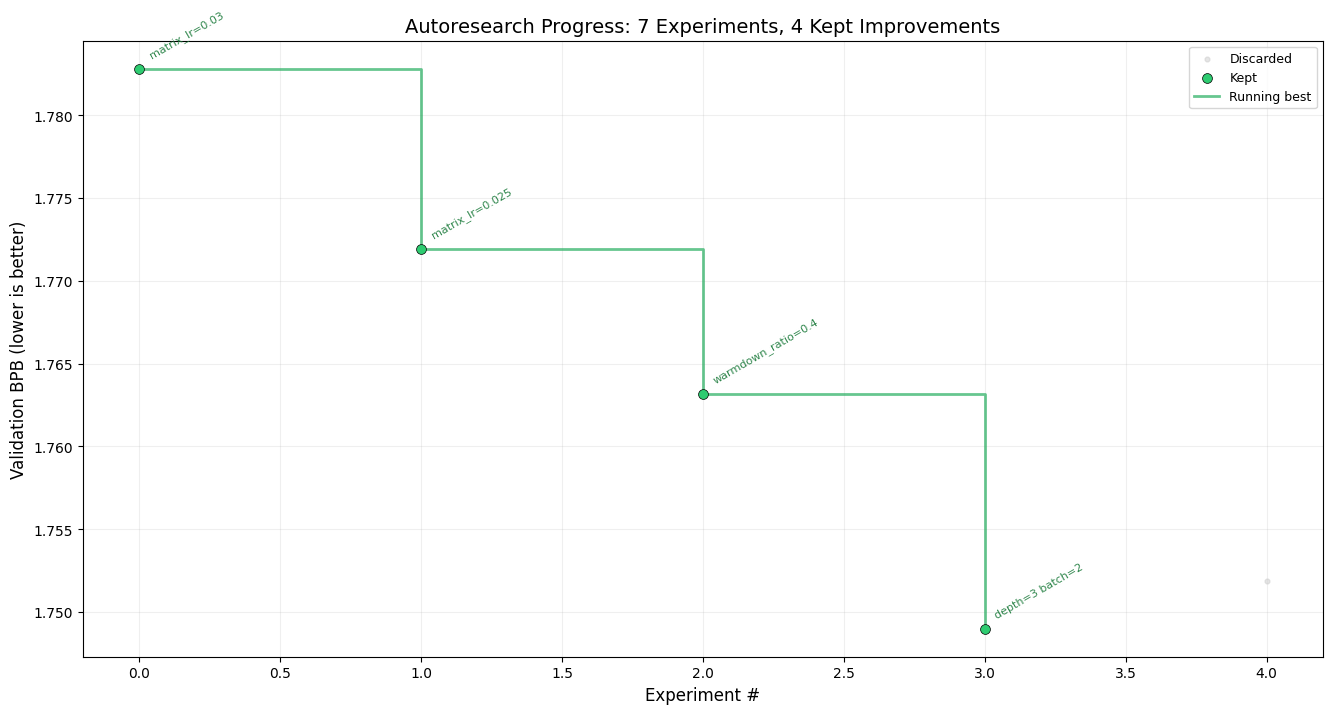

In [6]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_bpb = valid.loc[0, "val_bpb"]

# Only plot points at or below baseline (the interesting region)
below = valid[valid["val_bpb"] <= baseline_bpb + 0.0005]

# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc["val_bpb"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["val_bpb"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpb = valid.loc[kept_mask, "val_bpb"]
running_min = kept_bpb.cummin()
ax.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, bpb in zip(kept_idx, kept_bpb):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, bpb),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below best to just above baseline
margin = (baseline_bpb - best) * 0.15
ax.set_ylim(best - margin, baseline_bpb + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [7]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["val_bpb"]
best_bpb = kept["val_bpb"].min()
best_row = kept.loc[kept["val_bpb"].idxmin()]

print(f"Baseline val_bpb:  {baseline_bpb:.6f}")
print(f"Best val_bpb:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['val_bpb']:.6f}  {desc}")

Baseline val_bpb:  0.000000
Best val_bpb:      1.748980
Total improvement: -1.748980 (-inf%)
Best experiment:   depth=3 batch=2

Cumulative effort per improvement:
  Experiment #  2: bpb=1.782808  matrix_lr=0.03
  Experiment #  3: bpb=1.771936  matrix_lr=0.025
  Experiment #  4: bpb=1.763183  warmdown_ratio=0.4
  Experiment #  5: bpb=1.748980  depth=3 batch=2


C:\Users\admin\AppData\Local\Temp\ipykernel_28316\4275272150.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")


## Top Hits (Kept Experiments by Improvement)

In [8]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["val_bpb"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["val_bpb"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_bpb']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank     Delta         BPB  Description
--------------------------------------------------------------------------------
   1  +0.014203  1.748980  depth=3 batch=2
   2  +0.010872  1.771936  matrix_lr=0.025
   3  +0.008753  1.763183  warmdown_ratio=0.4

      +0.033828              TOTAL improvement over baseline
